# **FASTWOE — RECORRIDO COMPLETO DE CAPACIDADES**

Notebook de referencia sobre [**FastWoe**](https://github.com/xRiskLab/FastWoe) (xRiskLab, v0.1.8, MIT):
*encoding* Weight of Evidence + inferencia estadística, con foco en **scoring crediticio**.

Cada sección muestra una capacidad de la librería sobre un dataset crediticio público.
La comparación con la metodología propia de [`woe_example/utils.py`](../woe_example/utils.py)
está en el documento que acompaña este notebook: [`README.md`](README.md).

> **Atención al signo.** FastWoe define `WOE = ln(P(evento|bin) / P(no evento|bin)) − ln(P(evento) / P(no evento))`,
> con **evento = malo**. Tu `utils.py` usa `ln(%buenos / %malos)`. Son **convenciones opuestas**:
> acá el bin más riesgoso tiene **WOE positivo**. El detalle está en el `README.md`.

---
## **0. INSTALACIÓN EN EL KERNEL SELECCIONADO**

Usá la *magic* `%pip`, **no** `!pip`.

- `%pip` instala en el intérprete del kernel que tenés seleccionado arriba a la derecha.
- `!pip` va al `pip` que esté primero en el `PATH` del shell, que muchas veces **no** es el del kernel.
  Esa es la causa habitual del "lo instalé pero el `import` sigue fallando".

Si estás detrás de un proxy corporativo con inspección SSL y ves
`SSLCertVerificationError`, descomentá la segunda celda: agrega los *trusted hosts* de PyPI.

In [1]:
# Instalación estándar. El extra [plotting] trae matplotlib, necesario para las secciones 12 y 13.
%pip install "fastwoe[plotting]"

# Extras opcionales:
#   %pip install "fastwoe[faiss]"      # binning por KMeans (FAISS, CPU)
#   %pip install "fastwoe[faiss-gpu]"  # idem, con CUDA 12
#   %pip install "fastwoe[examples]"   # seaborn, jupyter, statsmodels, pygam

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.1.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
# Solo si la celda anterior falla con SSLCertVerificationError (proxy con inspección SSL).
# %pip install --trusted-host pypi.org --trusted-host files.pythonhosted.org "fastwoe[plotting]"

### Verificación de que la instalación cayó en el kernel correcto

`sys.executable` tiene que apuntar al Python del kernel seleccionado. Si `import fastwoe`
funciona acá, la instalación quedó bien.

In [3]:
import sys
import numpy as np
import pandas as pd
import sklearn
import fastwoe

print("Kernel  :", sys.executable)
print("Python  :", sys.version.split()[0])
print("fastwoe :", fastwoe.__version__)
print("sklearn :", sklearn.__version__, " (FastWoe requiere >=1.3.0, <1.8.0)")
print("pandas  :", pd.__version__)
print("numpy   :", np.__version__)

# Los 11 nombres públicos de la librería:
print("\n__all__ :", fastwoe.__all__)

Kernel  : c:\Users\HP\AppData\Local\Programs\Python\Python312\python.exe
Python  : 3.12.10
fastwoe : 0.1.8
sklearn : 1.7.2  (FastWoe requiere >=1.3.0, <1.8.0)
pandas  : 2.2.2
numpy   : 2.0.2

__all__ : ['FastWoe', 'WoePreprocessor', 'WeightOfEvidence', 'plot_performance', 'visualize_woe', 'StyledDataFrame', 'style_iv_analysis', 'style_woe_mapping', 'styled', 'iv_styled', 'gini_contributions']


In [4]:
import warnings
warnings.filterwarnings("ignore")

pd.set_option("display.width", 200)
pd.set_option("display.max_columns", 50)
pd.set_option("display.float_format", lambda v: f"{v:,.4f}")

RANDOM_STATE = 42

---
## **1. DATOS: GERMAN CREDIT (`credit-g`)**

Dataset crediticio público de OpenML: 1.000 solicitudes, 20 variables (13 categóricas + 7 numéricas),
target `good` / `bad`. Se elige porque **mezcla categóricas y numéricas** y es del dominio correcto.

Dos detalles importantes:

1. **El target se mapea a `1 = bad`**, es decir *evento = default*. 
2. Si no hay red (o el proxy bloquea OpenML), la celda **cae automáticamente a un dataset sintético**
   con el mismo esquema de columnas, para que el notebook corra igual de punta a punta.

> **Trampa a evitar: el dtype `category`.** OpenML devuelve las columnas categóricas con dtype
> `category` de pandas. En fastwoe 0.1.8, `predict_ci()` escribe valores *float* sobre las columnas
> de entrada, y pandas rechaza eso en una columna `category` con
> `TypeError: Cannot setitem on a Categorical with a new category`.
> `fit`, `transform` y `predict_proba` no se ven afectados — **solo rompe `predict_ci`**.
> Por eso el *loader* convierte `category` → `str`. Si traés datos de BigQuery con
> `dtype="category"`, te va a pasar lo mismo.

In [5]:
from sklearn.datasets import fetch_openml

def _normalizar_dtypes(df):
    '''
    Pasa las columnas 'category' de pandas a str.

    IMPORTANTE: no es cosmetico. En fastwoe 0.1.8, predict_ci() y
    WeightOfEvidence.predict_ci() escriben valores float sobre las columnas
    de entrada; si el dtype es 'category' pandas rechaza la asignacion con
    "Cannot setitem on a Categorical with a new category". credit-g viene de
    OpenML con dtype 'category', asi que sin esta conversion las secciones 8
    y 11 fallan. fit/transform/predict_proba andan igual: solo rompe predict_ci.
    '''
    cats = df.select_dtypes(include=["category"]).columns
    for c in cats:
        df[c] = df[c].astype(str)
    return df


def cargar_credit_g():
    '''Devuelve (X, y, origen). Cae a sintetico si no hay red.'''
    try:
        bunch = fetch_openml("credit-g", version=1, as_frame=True, parser="auto")
        df = bunch.frame.copy()
        # class: 'good' / 'bad'  ->  target: 0 / 1  (evento = bad = default)
        y = (df.pop("class") == "bad").astype(int).rename("target")
        return _normalizar_dtypes(df), y, "OpenML credit-g"
    except Exception as e:
        print(f"[aviso] No se pudo bajar credit-g ({type(e).__name__}). Uso dataset sintético.\n")
        return _credit_g_sintetico()


def _credit_g_sintetico(n=1000, seed=RANDOM_STATE):
    '''Replica sintetica con las mismas columnas y relaciones de riesgo conocidas.'''
    rng = np.random.default_rng(seed)
    df = pd.DataFrame({
        "duration":               rng.integers(4, 72, n),
        "credit_amount":          rng.lognormal(7.8, 0.6, n).round(),
        "age":                    rng.integers(19, 76, n),
        "installment_commitment": rng.integers(1, 5, n),
        "residence_since":        rng.integers(1, 5, n),
        "existing_credits":       rng.integers(1, 5, n),
        "num_dependents":         rng.integers(1, 3, n),
        "checking_status":        rng.choice(["<0", "0<=X<200", ">=200", "no checking"], n),
        "credit_history":         rng.choice(["critical/other existing credit", "existing paid",
                                              "delayed previously", "all paid", "no credits/all paid"], n),
        "purpose":                rng.choice(["radio/tv", "new car", "used car", "furniture/equipment",
                                              "business", "education", "repairs"], n),
        "savings_status":         rng.choice(["<100", "100<=X<500", "500<=X<1000", ">=1000", "no known savings"], n),
        "employment":             rng.choice(["unemployed", "<1", "1<=X<4", "4<=X<7", ">=7"], n),
        "personal_status":        rng.choice(["male single", "female div/dep/mar", "male div/sep"], n),
        "property_magnitude":     rng.choice(["real estate", "life insurance", "car", "no known property"], n),
        "housing":                rng.choice(["own", "rent", "for free"], n),
        "job":                    rng.choice(["skilled", "unskilled resident", "high qualif/self emp/mgmt"], n),
        "other_parties":          rng.choice(["none", "guarantor", "co applicant"], n),
        "other_payment_plans":    rng.choice(["none", "bank", "stores"], n),
        "own_telephone":          rng.choice(["yes", "none"], n),
        "foreign_worker":         rng.choice(["yes", "no"], n),
    })
    # Riesgo: plazo largo sube, edad alta baja, monto alto sube, sin cuenta corriente baja.
    logit = (-1.2
             + 0.030 * df["duration"]
             - 0.020 * (df["age"] - 35)
             + 0.00008 * df["credit_amount"]
             - 0.60 * (df["checking_status"] == "no checking")
             + 0.40 * (df["purpose"] == "business"))
    y = pd.Series(rng.binomial(1, 1 / (1 + np.exp(-logit))), name="target")
    return _normalizar_dtypes(df), y, "sintético (fallback sin red)"


X, y, ORIGEN = cargar_credit_g()
print(f"Origen : {ORIGEN}")
print(f"Shape  : {X.shape}")
print(f"Target : {y.value_counts().to_dict()}  ->  tasa de malos = {y.mean():.1%}")
X.head()

Origen : OpenML credit-g
Shape  : (1000, 20)
Target : {0: 700, 1: 300}  ->  tasa de malos = 30.0%


,checking_status,duration,credit_history,purpose,credit_amount,savings_status,employment,installment_commitment,personal_status,other_parties,residence_since,property_magnitude,age,other_payment_plans,housing,existing_credits,job,num_dependents,own_telephone,foreign_worker
0,<0,6,critical/other existing credit,radio/tv,1169,no known savings,>=7,4,male single,none,4,real estate,67,none,own,2,skilled,1,yes,yes
1,0<=X<200,48,existing paid,radio/tv,5951,<100,1<=X<4,2,female div/dep/mar,none,2,real estate,22,none,own,1,skilled,1,none,yes
2,no checking,12,critical/other existing credit,education,2096,<100,4<=X<7,2,male single,none,3,real estate,49,none,own,1,unskilled resident,2,none,yes
3,<0,42,existing paid,furniture/equipment,7882,<100,4<=X<7,2,male single,guarantor,4,life insurance,45,none,for free,1,skilled,2,none,yes
4,<0,24,delayed previously,new car,4870,<100,1<=X<4,3,male single,none,4,no known property,53,none,for free,2,skilled,2,none,yes


### Columna de alta cardinalidad

`credit-g` no trae ninguna variable con cardinalidad realmente alta (el máximo son ~10 niveles).
Para que la sección de `WoePreprocessor` tenga algo real que reducir, cruzamos dos categóricas
—`purpose` × `credit_history`—, que es *feature engineering* legítimo y no un dato inventado.

In [6]:
X["purpose_x_history"] = X["purpose"].astype(str) + " | " + X["credit_history"].astype(str)
print("Niveles de purpose_x_history:", X["purpose_x_history"].nunique())
X["purpose_x_history"].value_counts().head(8)

Niveles de purpose_x_history: 45


purpose_x_history
radio/tv | existing paid                                167
new car | existing paid                                 120
furniture/equipment | existing paid                     106
radio/tv | critical/other existing credit                80
new car | critical/other existing credit                 78
used car | existing paid                                 51
furniture/equipment | critical/other existing credit     50
used car | critical/other existing credit                36
Name: count, dtype: int64

### Partición train / test

El *split* no es decorativo: varias secciones muestran `fit` en **train** y `transform` en **test**.
Ese es justamente el mecanismo con el que FastWoe **congela los cortes** del binning, el equivalente
a tu `percentiles_precalculados` en `discretizar_variables`.

In [7]:
from sklearn.model_selection import train_test_split

X_tr, X_te, y_tr, y_te = train_test_split(
    X, y, test_size=0.30, stratify=y, random_state=RANDOM_STATE
)

NUM = X.select_dtypes(include=np.number).columns.tolist()
CAT = [c for c in X.columns if c not in NUM]

print(f"train {X_tr.shape} | test {X_te.shape}")
print(f"\nNuméricas ({len(NUM)}): {NUM}")
print(f"\nCategóricas ({len(CAT)}): {CAT}")

train (700, 21) | test (300, 21)

Numéricas (7): ['duration', 'credit_amount', 'installment_commitment', 'residence_since', 'age', 'existing_credits', 'num_dependents']

Categóricas (14): ['checking_status', 'credit_history', 'purpose', 'savings_status', 'employment', 'personal_status', 'other_parties', 'property_magnitude', 'other_payment_plans', 'housing', 'job', 'own_telephone', 'foreign_worker', 'purpose_x_history']


---
## **2. QUICK START: `fit_transform` Y `get_mapping`**

El camino mínimo. `FastWoe` es un *transformer* de scikit-learn: `fit`, `transform`, `fit_transform`.

Detecta sola qué columna es categórica y cuál numérica: toda numérica con **más de
`numerical_threshold` valores únicos** (default 20) se bincea antes de calcular el WOE.

In [8]:
from fastwoe import FastWoe

woe = FastWoe(random_state=RANDOM_STATE)
X_tr_woe = woe.fit_transform(X_tr, y_tr)

print("Antes :", X_tr.shape, "->  Después:", X_tr_woe.shape, " (mismo shape, valores reemplazados por WOE)")
X_tr_woe.head()

Antes : (700, 21) ->  Después: (700, 21)  (mismo shape, valores reemplazados por WOE)


,checking_status,duration,credit_history,purpose,credit_amount,savings_status,employment,installment_commitment,personal_status,other_parties,residence_since,property_magnitude,age,other_payment_plans,housing,existing_credits,job,num_dependents,own_telephone,foreign_worker,purpose_x_history
10,0.4152,-0.4998,0.0828,0.1804,0.3110,0.3018,0.5790,0.1001,0.2461,-0.0060,0.0715,0.0348,0.3185,-0.1746,0.4689,0.0355,-0.0396,-0.0057,0.0441,0.0450,0.3240
82,-1.1841,-0.2513,0.0828,0.2187,0.3110,0.0981,-0.0747,0.1001,0.2461,-0.0060,-0.0364,-0.0514,-11.8696,-0.1746,0.4689,0.0355,-0.1043,-0.0057,0.0441,0.0450,-0.6568
827,-1.1841,-0.2513,1.1350,0.2187,-14.8653,0.3018,-0.0747,-0.2118,-0.1634,-0.0060,-0.0153,0.0348,0.4261,0.3083,-0.2145,-0.0777,-0.0396,0.0299,0.0441,0.0450,1.6946
410,0.4152,-0.2513,0.0828,-0.3848,0.3110,0.3018,-0.1942,0.1495,0.2461,-0.0060,-0.0364,0.0348,-11.8696,-0.1746,-0.2145,0.0355,-0.0396,-0.0057,-0.0665,0.0450,-0.1132
48,-1.1841,-13.9490,-0.6991,0.1804,1.2891,0.3018,-0.0747,-0.2921,-0.1634,-0.0060,-0.0364,-0.0514,0.4261,-0.1746,-0.2145,-0.0777,-0.1043,-0.0057,0.0441,0.0450,-0.6788


`get_mapping(feature)` es el equivalente directo de una hoja de tu Excel de bivariados,
**pero con inferencia estadística incluida**.

Columnas que devuelve:

| Columna | Qué es |
|---|---|
| `category` | la categoría o el intervalo del bin |
| `count`, `count_pct` | volumen y participación del bin |
| `good_count`, `bad_count` | buenos y malos del bin |
| `event_rate` | tasa de malos del bin — tu `porcmalogrupo` |
| `woe` | Weight of Evidence (signo opuesto al tuyo) |
| `woe_se` | **error estándar del WOE** — esto no existe en `utils.py` |
| `woe_ci_lower`, `woe_ci_upper` | intervalo de confianza al 95 % |

In [9]:
woe.get_mapping("checking_status")

,category,count,count_pct,good_count,bad_count,event_rate,woe,woe_se,woe_ci_lower,woe_ci_upper
0,0<=X<200,188,26.8571,114,74,0.3936,0.4152,0.1493,0.1226,0.7078
1,<0,192,27.4286,100,92,0.4792,0.7639,0.1445,0.4808,1.0471
2,>=200,44,6.2857,32,12,0.2727,-0.1335,0.3385,-0.7970,0.5299
3,no checking,276,39.4286,244,32,0.1159,-1.1841,0.1880,-1.5526,-0.8156


In [10]:
# Para una numérica, las categorías son los intervalos que encontró el binning.
woe.get_mapping("duration")

,category,count,count_pct,good_count,bad_count,event_rate,woe,woe_se,woe_ci_lower,woe_ci_upper
0,"(-∞, 6.5]",58,8.2857,52,6,0.1034,-1.3122,0.4312,-2.1572,-0.4671
1,"(6.5, 8.5]",8,1.1429,8,0,0.0000,-13.9490,0.7303,-15.3804,-12.5177
2,"(8.5, 11.5]",63,9.0000,50,13,0.2063,-0.4998,0.3113,-1.1100,0.1104
3,"(11.5, 16.5]",180,25.7143,135,45,0.2500,-0.2513,0.1721,-0.5887,0.0861
4,"(16.5, 34.5]",272,38.8571,180,92,0.3382,0.1761,0.1282,-0.0751,0.4273
5,"(34.5, 47.5]",76,10.8571,45,31,0.4079,0.4746,0.2334,0.0171,0.9321
6,"(47.5, 57.0]",34,4.8571,15,19,0.5588,1.0837,0.3454,0.4067,1.7606
7,"(57.0, ∞)",9,1.2857,5,4,0.4444,0.6242,0.6708,-0.6906,1.9389


> **Cómo leer el `woe_se`.** Un bin con `woe_ci_lower` y `woe_ci_upper` de signos distintos
> tiene un WOE **no distinguible de cero** al 95 %: ese bin no está aportando evidencia,
> por más que su WOE puntual se vea grande. En tu Excel actual esa distinción no se puede hacer,
> y es la razón principal por la que bins chicos parecen informativos cuando no lo son.

---
## **3. ALTA CARDINALIDAD: `WoePreprocessor`**

Antes de calcular WOE conviene recortar las categorías raras: un nivel con 3 casos produce
un WOE enorme y completamente inestable. `WoePreprocessor` agrupa la cola en un token `__other__`.

Tres criterios, combinables:

| Parámetro | Efecto |
|---|---|
| `max_categories` | se queda con las N más frecuentes |
| `top_p` | se queda con las que cubren el `top_p` de la masa (default 0.95) |
| `min_count` | descarta las que tienen menos de N casos (default 10) |
| `other_token` | etiqueta del grupo residual (default `"__other__"`) |

In [11]:
from fastwoe import WoePreprocessor

prep = WoePreprocessor(top_p=0.95, min_count=15)

# cat_features permite aplicar la reducción SOLO a las columnas que te interesan.
prep.fit(X_tr[CAT], cat_features=["purpose_x_history"])

resumen = prep.get_reduction_summary(X_tr[CAT])
resumen

,feature,original_categories,kept_categories,reduction_pct
0,purpose_x_history,44,12,72.7273


In [12]:
X_tr_prep = prep.transform(X_tr[CAT])

antes  = X_tr["purpose_x_history"].nunique()
despues = X_tr_prep["purpose_x_history"].nunique()
print(f"purpose_x_history: {antes} niveles  ->  {despues} niveles")

X_tr_prep["purpose_x_history"].value_counts().tail(5)

purpose_x_history: 44 niveles  ->  13 niveles


purpose_x_history
used car | critical/other existing credit    26
business | existing paid                     22
business | delayed previously                21
education | existing paid                    17
radio/tv | delayed previously                15
Name: count, dtype: int64

In [13]:
# get_category_mapping() devuelve, por columna, las categorías que se conservan.
# Ojo: los valores son SETS de Python, no listas -> no se pueden indexar directamente.
mapa = prep.get_category_mapping()

pd.Series(
    {col: f"{len(cats)} conservadas: {sorted(cats)[:3]}..." for col, cats in mapa.items()},
    name="categorias_conservadas",
).to_frame()

,categorias_conservadas
purpose_x_history,12 conservadas: ['business | delayed previousl...


> **Ojo con el orden.** `WoePreprocessor` se fitea en **train** y se aplica a test. Una categoría
> que aparece solo en test cae automáticamente en `__other__`, que ya tiene un WOE estimado.
> Es el manejo de categorías no vistas que hoy en `aplicar_woe` te dejaría un `NaN`.

---
## **4. BINNING DE VARIABLES NUMÉRICAS**

Acá está la diferencia conceptual más grande con `discretizar_variables`: FastWoe bincea
**de forma supervisada** (mirando el target), no por percentiles ciegos.

| `binning_method` | Cómo corta | Cuándo usarlo |
|---|---|---|
| `"tree"` *(default)* | árbol de decisión: los cortes maximizan separación del target | scoring crediticio |
| `"kbins"` | `KBinsDiscretizer` de sklearn: `quantile`, `uniform` o `kmeans` | **el más parecido a tu `metodo='quantile'`** |
| `"faiss_kmeans"` | clustering KMeans con FAISS (CPU/GPU) | volúmenes muy grandes |

`numerical_threshold` (default 20) define a partir de cuántos valores únicos una numérica se bincea.

In [14]:
# --- A) Binning por árbol (supervisado, default)
woe_tree = FastWoe(
    binning_method="tree",
    tree_kwargs={"max_depth": 3, "min_samples_leaf": 40},
    random_state=RANDOM_STATE,
)
woe_tree.fit(X_tr, y_tr)

woe_tree.get_binning_summary()

,feature,values,n_bins,missing,method,monotonic_constraint
0,duration,30,6,0,tree,0
1,credit_amount,658,6,0,tree,0
2,age,52,6,0,tree,0


In [15]:
# --- B) Binning por cuantiles: el equivalente a tu metodo='quantile' con n_bins=5
woe_kbins = FastWoe(
    binning_method="kbins",
    binner_kwargs={"n_bins": 5, "strategy": "quantile", "encode": "ordinal"},
    random_state=RANDOM_STATE,
)
woe_kbins.fit(X_tr, y_tr)

print("Cortes por cuantiles (equivalente a pd.qcut(q=5)):")
woe_kbins.get_mapping("duration")

Cortes por cuantiles (equivalente a pd.qcut(q=5)):


,category,count,count_pct,good_count,bad_count,event_rate,woe,woe_se,woe_ci_lower,woe_ci_upper
0,"(-∞, 12.0]",129,18.4286,110,19,0.1473,-0.9087,0.2484,-1.3957,-0.4218
1,"(12.0, 15.0]",135,19.2857,100,35,0.2593,-0.2025,0.1964,-0.5875,0.1824
2,"(15.0, 24.0]",145,20.7143,99,46,0.3172,0.0808,0.1784,-0.2689,0.4306
3,"(24.0, 30.0]",141,20.1429,95,46,0.3262,0.1221,0.1796,-0.2300,0.4741
4,"(30.0, ∞)",150,21.4286,86,64,0.4267,0.5518,0.1651,0.2283,0.8754


In [16]:
# --- Comparación directa de los dos criterios sobre la misma variable
comp = pd.concat([
    woe_tree.get_mapping("duration").assign(metodo="tree")[["metodo", "category", "count", "event_rate", "woe"]],
    woe_kbins.get_mapping("duration").assign(metodo="kbins")[["metodo", "category", "count", "event_rate", "woe"]],
], ignore_index=True)
comp

,metodo,category,count,event_rate,woe
0,tree,"(-∞, 8.5]",66,0.0909,-1.4553
1,tree,"(8.5, 11.5]",63,0.2063,-0.4998
2,tree,"(11.5, 16.5]",180,0.2500,-0.2513
3,tree,"(16.5, 34.5]",272,0.3382,0.1761
4,tree,"(34.5, 47.5]",76,0.4079,0.4746
5,tree,"(47.5, ∞)",43,0.5349,0.9871
6,kbins,"(-∞, 12.0]",129,0.1473,-0.9087
7,kbins,"(12.0, 15.0]",135,0.2593,-0.2025
8,kbins,"(15.0, 24.0]",145,0.3172,0.0808
9,kbins,"(24.0, 30.0]",141,0.3262,0.1221


Con `binning_method="tree"` podés además inspeccionar el árbol que produjo los cortes:

In [17]:
# Los puntos de corte exactos, listos para traducir a un CASE WHEN de SQL.
cortes = woe_tree.get_split_value_histogram("duration", as_array=True)
print("duration      :", cortes)
print("credit_amount :", woe_tree.get_split_value_histogram("credit_amount"))

# Y el estimador sklearn subyacente, por si querés graficarlo o auditarlo.
arbol = woe_tree.get_tree_estimator("duration")
print("\nEstimador:", type(arbol).__name__, "| profundidad:", arbol.get_depth(), "| hojas:", arbol.get_n_leaves())

duration      : [-inf  8.5 11.5 16.5 34.5 47.5  inf]
credit_amount : [  -inf  959.5 3422.  3913.5 5297.5 7760.5    inf]

Estimador: DecisionTreeClassifier | profundidad: 3 | hojas: 6


In [18]:
%pip install "fastwoe[faiss]


[notice] A new release of pip is available: 25.1.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [19]:
# --- C) FAISS KMeans (requiere el extra [faiss]; se saltea si no está instalado)
try:
    woe_faiss = FastWoe(
        binning_method="faiss_kmeans",
        faiss_kwargs={"k": 5, "niter": 20, "verbose": False, "gpu": False},
        random_state=RANDOM_STATE,
    )
    woe_faiss.fit(X_tr[NUM], y_tr)
    display(woe_faiss.get_binning_summary())
except ImportError:
    print("FAISS no instalado. Para probarlo:  %pip install \"fastwoe[faiss]\"")
except Exception as e:
    print(f"FAISS no disponible ({type(e).__name__}): {e}")

,feature,values,n_bins,missing,method,monotonic_constraint
0,duration,30,5,0,faiss_kmeans,0
1,credit_amount,658,5,0,faiss_kmeans,0
2,age,52,5,0,faiss_kmeans,0


> **Qué te sirve de acá.** `get_split_value_histogram()` te devuelve los cortes como array.
> Eso es exactamente lo que necesitás para escribir el `CASE WHEN` en BigQuery: podés dejar que
> el árbol elija los cortes en Python y después **materializarlos como constantes en SQL**,
> sin depender de `PERCENTILE_CONT` en tiempo de ejecución.

---
## **5. MONOTONICIDAD FORZADA (`monotonic_cst`)**

Requisito duro de cualquier *scorecard* que vaya a validación: el riesgo tiene que moverse en una
sola dirección a lo largo de los bins. Hoy vos verificás esto **a ojo**, con la escala de color
verde-amarillo-rojo del Excel. FastWoe lo **impone en el binning**.

- `1` → el riesgo **crece** con la variable
- `-1` → el riesgo **decrece**
- `0` → sin restricción

**Solo funciona con `binning_method="tree"`.**

In [20]:
woe_mono = FastWoe(
    binning_method="tree",
    monotonic_cst={
        "duration": 1,       # más plazo  -> más riesgo
        "age": -1,           # más edad   -> menos riesgo
        "credit_amount": 1,  # más monto  -> más riesgo
    },
    numerical_threshold=10,
    random_state=RANDOM_STATE,
)
woe_mono.fit(X_tr, y_tr)

woe_mono.get_binning_summary()[["feature", "n_bins", "method", "monotonic_constraint"]]

,feature,n_bins,method,monotonic_constraint
0,duration,7,tree,1
1,credit_amount,6,tree,1
2,age,5,tree,-1


In [21]:
# Verificación: el WOE ahora es monótono creciente a lo largo de los bins de duration.
m = woe_mono.get_mapping("duration")
m[["category", "count", "event_rate", "woe", "woe_ci_lower", "woe_ci_upper"]]

,category,count,event_rate,woe,woe_ci_lower,woe_ci_upper
0,"(-∞, 5.0]",5,0.0000,-13.4790,-15.2682,-11.6898
1,"(5.0, 8.5]",61,0.0984,-1.3683,-2.2109,-0.5256
2,"(8.5, 11.5]",63,0.2063,-0.4998,-1.1100,0.1104
3,"(11.5, 16.5]",180,0.2500,-0.2513,-0.5887,0.0861
4,"(16.5, 34.5]",272,0.3382,0.1761,-0.0751,0.4273
5,"(34.5, 47.5]",76,0.4079,0.4746,0.0171,0.9321
6,"(47.5, ∞)",43,0.5349,0.9871,0.3878,1.5863


In [22]:
# Sin restricción vs con restricción, lado a lado.
sin_r = woe_tree.get_mapping("age")[["category", "count", "event_rate", "woe"]]
con_r = woe_mono.get_mapping("age")[["category", "count", "event_rate", "woe"]]

print("--- age SIN restricción ---");  display(sin_r)
print("--- age CON monotonic_cst=-1 ---"); display(con_r)

def es_monotona(serie):
    d = serie.diff().dropna()
    return "creciente" if (d >= 0).all() else ("decreciente" if (d <= 0).all() else "NO monótona")

print("WOE sin restricción :", es_monotona(sin_r["woe"]))
print("WOE con restricción :", es_monotona(con_r["woe"]))

--- age SIN restricción ---


,category,count,event_rate,woe
0,"(-∞, 23.5]",64,0.3594,0.2692
1,"(23.5, 25.5]",60,0.4500,0.6466
2,"(25.5, 32.5]",208,0.2933,-0.0323
3,"(32.5, 34.5]",53,0.3962,0.4261
4,"(34.5, 52.5]",254,0.2205,-0.4156
5,"(52.5, ∞)",61,0.3607,0.2748


--- age CON monotonic_cst=-1 ---


,category,count,event_rate,woe
0,"(-∞, 25.5]",124,0.4032,0.4553
1,"(25.5, 29.5]",123,0.3252,0.1173
2,"(29.5, 34.5]",138,0.3043,0.0206
3,"(34.5, 74.5]",314,0.2484,-0.2598
4,"(74.5, ∞)",1,0.0000,-11.8696


WOE sin restricción : NO monótona
WOE con restricción : decreciente


---
## **6. INFERENCIA ESTADÍSTICA: IV CON ERROR ESTÁNDAR Y SIGNIFICANCIA**

Esta es la sección que más se aleja de `utils.py`. Tu `iv_total_variable` es un número puntual
que ordena variables; acá el IV viene con **error estándar, intervalo de confianza y un veredicto
de significancia**, más el Gini y el Somers' D de cada variable.

In [23]:
# Estadísticas completas por variable.
stats = woe.get_feature_stats()
stats

,feature,n_categories,total_observations,missing_count,missing_rate,gini,somersd_se,somersd_ci_lower,somersd_ci_upper,iv,iv_se,iv_ci_lower,iv_ci_upper,min_woe,max_woe
0,checking_status,4,700,0,0.0000,0.4023,0.0499,0.3045,0.5000,0.6388,0.0917,0.4591,0.8184,-1.1841,0.7639
1,duration,8,700,0,0.0000,0.2643,0.0471,0.1719,0.3566,0.2465,0.0616,0.1258,0.3673,-13.9490,1.0837
2,credit_history,5,700,0,0.0000,0.2426,0.0455,0.1533,0.3318,0.2544,0.0594,0.1381,0.3707,-0.6991,1.1350
3,purpose,10,700,0,0.0000,0.1882,0.0476,0.0948,0.2815,0.1322,0.0420,0.0499,0.2146,-0.5555,0.9045
4,credit_amount,8,700,0,0.0000,0.2387,0.0456,0.1493,0.3281,0.4430,0.1463,0.1562,0.7298,-14.8653,14.1032
5,savings_status,5,700,0,0.0000,0.2186,0.0412,0.1378,0.2995,0.2335,0.0551,0.1255,0.3414,-1.0090,0.3018
6,employment,5,700,0,0.0000,0.1940,0.0478,0.1004,0.2876,0.1403,0.0425,0.0571,0.2235,-0.5170,0.6848
7,installment_commitment,4,700,0,0.0000,0.0933,0.0444,0.0062,0.1804,0.0338,0.0200,0.0000,0.0730,-0.2921,0.1495
8,personal_status,4,700,0,0.0000,0.0999,0.0438,0.0139,0.1858,0.0392,0.0210,0.0000,0.0803,-0.1634,0.3083
9,other_parties,3,700,0,0.0000,0.0467,0.0242,-0.0007,0.0941,0.0267,0.0192,0.0000,0.0643,-0.5026,0.5790


In [24]:
# Versión compacta, ordenada por poder predictivo. Equivale a tu ranking por iv_total_variable.
woe.get_feature_summary()

,feature,gini,iv,n_categories
0,checking_status,0.4023,0.6388,4
20,purpose_x_history,0.4017,0.9713,44
1,duration,0.2643,0.2465,8
2,credit_history,0.2426,0.2544,5
4,credit_amount,0.2387,0.4430,8
5,savings_status,0.2186,0.2335,5
12,age,0.1987,0.1562,7
6,employment,0.1940,0.1403,5
11,property_magnitude,0.1939,0.1402,4
3,purpose,0.1882,0.1322,10


In [25]:
# El análisis que no podés hacer hoy: ¿este IV es distinguible de cero?
iv = woe.get_iv_analysis(alpha=0.05)
iv

,feature,iv,iv_se,iv_ci_lower,iv_ci_upper,iv_significance,n_categories,gini
20,purpose_x_history,0.9713,0.1719,0.6345,1.3082,Significant,44,0.4017
0,checking_status,0.6388,0.0917,0.4591,0.8184,Significant,4,0.4023
4,credit_amount,0.4430,0.1463,0.1562,0.7298,Significant,8,0.2387
2,credit_history,0.2544,0.0594,0.1381,0.3707,Significant,5,0.2426
1,duration,0.2465,0.0616,0.1258,0.3673,Significant,8,0.2643
5,savings_status,0.2335,0.0551,0.1255,0.3414,Significant,5,0.2186
12,age,0.1562,0.0478,0.0625,0.2499,Significant,7,0.1987
6,employment,0.1403,0.0425,0.0571,0.2235,Significant,5,0.1940
11,property_magnitude,0.1402,0.0419,0.0581,0.2223,Significant,4,0.1939
3,purpose,0.1322,0.0420,0.0499,0.2146,Significant,10,0.1882


In [26]:
# Lectura contra los umbrales clásicos de Siddiqi.
def fuerza_iv(v):
    if v < 0.02:  return "inútil"
    if v < 0.10:  return "débil"
    if v < 0.30:  return "media"
    if v < 0.50:  return "fuerte"
    return "sospechosa (revisar leakage)"

tabla = iv[["feature", "iv", "iv_ci_lower", "iv_ci_upper", "iv_significance"]].copy()
tabla["fuerza"] = tabla["iv"].map(fuerza_iv)
tabla

,feature,iv,iv_ci_lower,iv_ci_upper,iv_significance,fuerza
20,purpose_x_history,0.9713,0.6345,1.3082,Significant,sospechosa (revisar leakage)
0,checking_status,0.6388,0.4591,0.8184,Significant,sospechosa (revisar leakage)
4,credit_amount,0.4430,0.1562,0.7298,Significant,fuerte
2,credit_history,0.2544,0.1381,0.3707,Significant,media
1,duration,0.2465,0.1258,0.3673,Significant,media
5,savings_status,0.2335,0.1255,0.3414,Significant,media
12,age,0.1562,0.0625,0.2499,Significant,media
6,employment,0.1403,0.0571,0.2235,Significant,media
11,property_magnitude,0.1402,0.0581,0.2223,Significant,media
3,purpose,0.1322,0.0499,0.2146,Significant,media


> **El punto importante.** Una variable puede tener IV = 0,04 (*"débil pero la dejo"*) y a la vez
> `iv_significance = "Not Significant"`, es decir un IV **estadísticamente indistinguible de cero**.
> Ese es ruido que se te cuela en el modelo. Con tu IV puntual —y encima en escala ×100— esa
> variable se ve igual que una genuinamente débil pero real.

In [27]:
# También podés pedir el detalle de una sola variable.
woe.get_iv_analysis("purpose")

,feature,iv,iv_se,iv_ci_lower,iv_ci_upper,iv_significance,n_categories,gini
0,purpose,0.1322,0.0420,0.0499,0.2146,Significant,10,0.1882


In [28]:
# get_probability_mapping: en vez del WOE, la probabilidad de evento por categoría.
woe.get_probability_mapping("checking_status")

,category,count,count_pct,probability,probability_se
category,,,,,
0<=X<200,0<=X<200,188,26.8571,0.3936,0.0356
<0,<0,192,27.4286,0.4792,0.0361
>=200,>=200,44,6.2857,0.2727,0.0671
no checking,no checking,276,39.4286,0.1159,0.0193


In [29]:
# get_all_mappings: el diccionario completo {variable: DataFrame}.
# Es el equivalente de tu calcular_woe_mapping(), pero ya calculado dentro del fit.
todos = woe.get_all_mappings()
print(f"{len(todos)} variables mapeadas")
print(list(todos.keys()))

21 variables mapeadas
['checking_status', 'duration', 'credit_history', 'purpose', 'credit_amount', 'savings_status', 'employment', 'installment_commitment', 'personal_status', 'other_parties', 'residence_since', 'property_magnitude', 'age', 'other_payment_plans', 'housing', 'existing_credits', 'job', 'num_dependents', 'own_telephone', 'foreign_worker', 'purpose_x_history']


---
## **7. MODOS DE SALIDA DE `transform`**

`transform(X, output=...)` no devuelve solo el WOE. Los cinco modos:

| `output` | Qué devuelve |
|---|---|
| `"woe"` *(default)* | el WOE del bin |
| `"woe_norm"` | WOE / SE — WOE **normalizado por su incertidumbre** |
| `"wald"` | estadístico de Wald: `(WOE + log-odds prior) / SE` |
| `"woe_upper_ci"` | cota superior del IC 95 % |
| `"woe_lower_ci"` | cota inferior del IC 95 % |

In [30]:
modos = ["woe", "woe_norm", "wald", "woe_upper_ci", "woe_lower_ci"]
salidas = {m: woe.transform(X_te, output=m)["duration"] for m in modos}

pd.DataFrame(salidas, index=X_te.index).head(10)

,woe,woe_norm,wald,woe_upper_ci,woe_lower_ci
115,0.4746,2.0334,-1.5967,0.9321,0.0171
346,-0.4998,-1.6053,-4.3269,0.1104,-1.1100
328,0.1761,1.3743,-5.2369,0.4273,-0.0751
974,-0.2513,-1.4600,-6.3824,0.0861,-0.5887
587,-0.4998,-1.6053,-4.3269,0.1104,-1.1100
259,-13.9490,-19.1005,-20.2607,-12.5177,-15.3804
52,-0.4998,-1.6053,-4.3269,0.1104,-1.1100
455,-0.2513,-1.4600,-6.3824,0.0861,-0.5887
341,-0.2513,-1.4600,-6.3824,0.0861,-0.5887
677,1.0837,3.1375,0.6844,1.7606,0.4067


`"woe_norm"` es el modo con más valor práctico: penaliza los bins con pocos casos. Un WOE de 1,5
estimado sobre 12 observaciones tiene un SE grande, así que su WOE normalizado queda chico.
Es una forma de *shrinkage* implícito que hoy no tenés.

In [31]:
# Efecto del shrinkage: bins chicos pierden peso al normalizar.
m = woe.get_mapping("purpose_x_history").copy()
m["woe_norm"] = m["woe"] / m["woe_se"]
m[["category", "count", "woe", "woe_se", "woe_norm"]].sort_values("count").head(10)

,category,count,woe,woe_se,woe_norm
6,domestic appliance | critical/other existing c...,1,-11.8696,1.0000,-11.8696
5,domestic appliance | all paid,1,-11.8696,1.0000,-11.8696
25,other | existing paid,1,-11.8696,1.0000,-11.8696
22,other | all paid,1,12.7169,1.0000,12.7169
36,retraining | critical/other existing credit,1,-11.8696,1.0000,-11.8696
37,retraining | existing paid,1,12.7169,1.0000,12.7169
38,retraining | no credits/all paid,1,-11.8696,1.0000,-11.8696
34,repairs | no credits/all paid,1,-11.8696,1.0000,-11.8696
23,other | critical/other existing credit,2,0.8473,1.4142,0.5991
24,other | delayed previously,2,-12.5628,1.0000,-12.5628


In [32]:
# transform_standardized: versión estandarizada, útil para comparar magnitudes entre variables.
woe.transform_standardized(X_te).head()

,checking_status,duration,credit_history,purpose,credit_amount,savings_status,employment,installment_commitment,personal_status,other_parties,residence_since,property_magnitude,age,other_payment_plans,housing,existing_credits,job,num_dependents,own_telephone,foreign_worker,purpose_x_history
115,-6.2982,2.0334,-3.8084,-2.1945,-1.8692,-3.4584,-1.1565,1.2635,-1.4201,-0.0692,0.3184,-2.7128,1.5172,-1.8278,-2.0997,0.3437,-0.3810,-0.0629,-0.5058,0.5387,-2.9622
346,2.7811,-1.6053,-3.8084,-2.1945,1.3754,2.9702,3.1432,1.2635,-1.4201,-1.1851,-0.2753,-2.7128,-11.8696,-1.8278,-2.0997,-0.5458,-0.3810,-0.0629,0.4167,0.5387,-2.9622
328,-0.3945,1.3743,0.7338,-2.1945,3.0173,2.9702,-1.1565,1.2635,-1.4201,-0.0692,-0.1032,0.2441,2.4703,-1.8278,-2.0997,0.3437,-0.3810,-0.0629,0.4167,0.5387,-0.5358
974,-6.2982,-1.4600,-3.8084,-2.1945,1.3754,2.9702,-0.5286,1.2635,1.7014,-0.0692,-0.1032,0.2441,-0.2118,-1.8278,-2.0997,0.3437,-0.3810,-0.0629,-0.5058,0.5387,-2.9622
587,5.2880,-1.6053,0.7338,0.6217,1.3754,2.9702,-0.5286,1.2635,-1.4201,-1.1851,0.3184,-0.2942,-11.8696,-1.8278,-2.0997,0.3437,-0.5530,-0.0629,0.4167,0.5387,0.9560


---
## **8. PREDICCIÓN E INTERVALOS DE CONFIANZA**

`FastWoe` no es solo un *encoder*: sumando los WOE de todos los bins de un caso obtiene un score
y, vía Naive Bayes, una probabilidad. Sirve como **baseline instantáneo** contra el cual medir
cualquier modelo posterior.

In [33]:
proba = woe.predict_proba(X_te)          # (n, 2) -> columna 1 = P(malo)
pred  = woe.predict(X_te)                # clase predicha
ci    = woe.predict_ci(X_te, alpha=0.05) # ndarray (n, 2) -> [inferior, superior]

print("predict_proba:", proba.shape, "| predict_ci:", type(ci).__name__, ci.shape)

resultado = pd.DataFrame({
    "p_malo":   proba[:, 1],
    "ci_lower": ci[:, 0],
    "ci_upper": ci[:, 1],
    "pred":     pred,
    "real":     y_te.values,
}, index=X_te.index)
resultado.head(10)

predict_proba: (300, 2) | predict_ci: ndarray (300, 2)


,p_malo,ci_lower,ci_upper,pred,real
115,0.0033,0.0006,0.0175,0,0
346,0.0000,0.0000,0.0000,0,0
328,0.6713,0.2833,0.9134,1,0
974,0.0139,0.0030,0.0612,0,0
587,0.0000,0.0000,0.0001,0,0
259,0.0000,0.0000,0.0000,0,0
52,0.0795,0.0205,0.2622,0,0
455,0.4520,0.1287,0.8216,1,0
341,0.6849,0.3245,0.9078,1,0
677,0.0000,0.0000,0.0002,0,1


> **Corrección al README oficial de FastWoe.** La documentación del repo muestra
> `ci_results[['prediction', 'lower_ci', 'upper_ci']]`, como si `predict_ci` devolviera un DataFrame.
> En la versión 0.1.8 devuelve un **`np.ndarray` de shape (n, 2)**. Verificado contra la librería instalada.

In [34]:
from sklearn.metrics import roc_auc_score

auc  = roc_auc_score(y_te, proba[:, 1])
gini = 2 * auc - 1
print(f"Baseline WOE + Naive Bayes  ->  AUC = {auc:.4f} | Gini = {gini:.4f}")

# Ancho del intervalo: cuánta incertidumbre arrastra cada predicción.
ancho = ci[:, 1] - ci[:, 0]
print(f"\nAncho del IC 95%: mediana = {np.median(ancho):.4f} | máximo = {ancho.max():.4f}")
print("Los casos con IC más ancho son los que caen en bins con poca población.")

Baseline WOE + Naive Bayes  ->  AUC = 0.6046 | Gini = 0.2091

Ancho del IC 95%: mediana = 0.2401 | máximo = 0.9305
Los casos con IC más ancho son los que caen en bins con poca población.


---
## **9. WOE PIECEWISE**

El *trade-off* clásico al pasar a regresión logística:

- **WOE clásico**: 1 columna por variable → 1 solo coeficiente → asume que el WOE ya captura toda la forma.
- **Dummies**: 1 columna por bin → máxima flexibilidad → explosión de parámetros y sobreajuste.

El **piecewise WOE** (Raymond Anderson, Standard Bank) es el punto medio: agrupa los bins en
*pieces* y le da a la logística **un coeficiente por pieza**.

`assign_pieces(strategy="sign")` parte por el signo del WOE: bins con WOE < 0 en la pieza 0,
bins con WOE ≥ 0 en la pieza 1.

In [35]:
woe_pw = FastWoe(random_state=RANDOM_STATE)
woe_pw.fit(X_tr, y_tr)
woe_pw.assign_pieces(strategy="sign")

# La asignación queda en mappings_, como una columna extra 'piece'.
woe_pw.mappings_["duration"][["count", "event_rate", "woe", "piece"]]

,count,event_rate,woe,piece
category,,,,
"(-∞, 6.5]",58,0.1034,-1.3122,0
"(11.5, 16.5]",180,0.2500,-0.2513,0
"(16.5, 34.5]",272,0.3382,0.1761,1
"(34.5, 47.5]",76,0.4079,0.4746,1
"(47.5, 57.0]",34,0.5588,1.0837,1
"(57.0, ∞)",9,0.4444,0.6242,1
"(6.5, 8.5]",8,0.0000,-13.9490,0
"(8.5, 11.5]",63,0.2063,-0.4998,0


In [36]:
X_tr_pw = woe_pw.transform(X_tr, output="piecewise")
X_te_pw = woe_pw.transform(X_te, output="piecewise")

print(f"WOE clásico : {X_tr_woe.shape[1]} columnas")
print(f"Piecewise   : {X_tr_pw.shape[1]} columnas")
print(f"\nNomenclatura: {list(X_tr_pw.columns)[:6]}")
X_tr_pw.head()

WOE clásico : 21 columnas
Piecewise   : 42 columnas

Nomenclatura: ['checking_status__piece_0', 'checking_status__piece_1', 'duration__piece_0', 'duration__piece_1', 'credit_history__piece_0', 'credit_history__piece_1']


,checking_status__piece_0,checking_status__piece_1,duration__piece_0,duration__piece_1,credit_history__piece_0,credit_history__piece_1,purpose__piece_0,purpose__piece_1,credit_amount__piece_0,credit_amount__piece_1,savings_status__piece_0,savings_status__piece_1,employment__piece_0,employment__piece_1,installment_commitment__piece_0,installment_commitment__piece_1,personal_status__piece_0,personal_status__piece_1,other_parties__piece_0,other_parties__piece_1,residence_since__piece_0,residence_since__piece_1,property_magnitude__piece_0,property_magnitude__piece_1,age__piece_0,age__piece_1,other_payment_plans__piece_0,other_payment_plans__piece_1,housing__piece_0,housing__piece_1,existing_credits__piece_0,existing_credits__piece_1,job__piece_0,job__piece_1,num_dependents__piece_0,num_dependents__piece_1,own_telephone__piece_0,own_telephone__piece_1,foreign_worker__piece_0,foreign_worker__piece_1,purpose_x_history__piece_0,purpose_x_history__piece_1
10,0.0000,0.4152,-0.4998,0.0000,0.0000,0.0828,0.0000,0.1804,0.0000,0.3110,0.0000,0.3018,0.0000,0.5790,0.0000,0.1001,0.0000,0.2461,-0.0060,0.0000,0.0000,0.0715,0.0000,0.0348,0.0000,0.3185,-0.1746,0.0000,0.0000,0.4689,0.0000,0.0355,-0.0396,0.0000,-0.0057,0.0000,0.0000,0.0441,0.0000,0.0450,0.0000,0.3240
82,-1.1841,0.0000,-0.2513,0.0000,0.0000,0.0828,0.0000,0.2187,0.0000,0.3110,0.0000,0.0981,-0.0747,0.0000,0.0000,0.1001,0.0000,0.2461,-0.0060,0.0000,-0.0364,0.0000,-0.0514,0.0000,-11.8696,0.0000,-0.1746,0.0000,0.0000,0.4689,0.0000,0.0355,-0.1043,0.0000,-0.0057,0.0000,0.0000,0.0441,0.0000,0.0450,-0.6568,0.0000
827,-1.1841,0.0000,-0.2513,0.0000,0.0000,1.1350,0.0000,0.2187,-14.8653,0.0000,0.0000,0.3018,-0.0747,0.0000,-0.2118,0.0000,-0.1634,0.0000,-0.0060,0.0000,-0.0153,0.0000,0.0000,0.0348,0.0000,0.4261,0.0000,0.3083,-0.2145,0.0000,-0.0777,0.0000,-0.0396,0.0000,0.0000,0.0299,0.0000,0.0441,0.0000,0.0450,0.0000,1.6946
410,0.0000,0.4152,-0.2513,0.0000,0.0000,0.0828,-0.3848,0.0000,0.0000,0.3110,0.0000,0.3018,-0.1942,0.0000,0.0000,0.1495,0.0000,0.2461,-0.0060,0.0000,-0.0364,0.0000,0.0000,0.0348,-11.8696,0.0000,-0.1746,0.0000,-0.2145,0.0000,0.0000,0.0355,-0.0396,0.0000,-0.0057,0.0000,-0.0665,0.0000,0.0000,0.0450,-0.1132,0.0000
48,-1.1841,0.0000,-13.9490,0.0000,-0.6991,0.0000,0.0000,0.1804,0.0000,1.2891,0.0000,0.3018,-0.0747,0.0000,-0.2921,0.0000,-0.1634,0.0000,-0.0060,0.0000,-0.0364,0.0000,-0.0514,0.0000,0.0000,0.4261,-0.1746,0.0000,-0.2145,0.0000,-0.0777,0.0000,-0.1043,0.0000,-0.0057,0.0000,0.0000,0.0441,0.0000,0.0450,-0.6788,0.0000


In [37]:
from sklearn.linear_model import LogisticRegression

# penalty=None: queremos los coeficientes crudos, sin regularización.
lr_pw = LogisticRegression(penalty=None, max_iter=1000).fit(X_tr_pw, y_tr)
lr_cl = LogisticRegression(penalty=None, max_iter=1000).fit(woe_pw.transform(X_tr), y_tr)

auc_pw = roc_auc_score(y_te, lr_pw.predict_proba(X_te_pw)[:, 1])
auc_cl = roc_auc_score(y_te, lr_cl.predict_proba(woe_pw.transform(X_te))[:, 1])

print(f"Logística sobre WOE clásico  : AUC test = {auc_cl:.4f} | Gini = {2*auc_cl-1:.4f}")
print(f"Logística sobre WOE piecewise: AUC test = {auc_pw:.4f} | Gini = {2*auc_pw-1:.4f}")

Logística sobre WOE clásico  : AUC test = 0.7084 | Gini = 0.4167
Logística sobre WOE piecewise: AUC test = 0.7206 | Gini = 0.4413


In [38]:
# Coeficientes por pieza: en WOE clásico bien construido deberían dar cerca de 1.
coefs = pd.DataFrame({"columna": X_tr_pw.columns, "coef": lr_pw.coef_[0]})
coefs.sort_values("coef", key=np.abs, ascending=False).head(12)

,columna,coef
20,residence_since__piece_0,32.2366
28,housing__piece_0,21.6772
21,residence_since__piece_1,-15.9740
29,housing__piece_1,-8.8969
30,existing_credits__piece_0,-7.1503
32,job__piece_0,-3.9237
16,personal_status__piece_0,3.1408
31,existing_credits__piece_1,2.8927
14,installment_commitment__piece_0,2.4430
36,own_telephone__piece_0,2.3515


In [39]:
# También podés definir las piezas a mano, con piece_map.
cats_ch = list(woe_pw.mappings_["checking_status"].index)
print("Categorías de checking_status:", cats_ch)

woe_pw.assign_pieces(piece_map={
    "checking_status": {c: (0 if i < len(cats_ch) // 2 else 1) for i, c in enumerate(cats_ch)}
})
woe_pw.mappings_["checking_status"][["count", "woe", "piece"]]

Categorías de checking_status: ['0<=X<200', '<0', '>=200', 'no checking']


,count,woe,piece
category,,,
0<=X<200,188,0.4152,0
<0,192,0.7639,0
>=200,44,-0.1335,1
no checking,276,-1.1841,1


> **Por qué esto importa para tu repo.** Tus resúmenes marcan que el paso de WOE a regresión
> logística no está implementado en `woe_example`. El piecewise WOE es exactamente ese puente,
> y es el tema central del capítulo 2 del libro
> ([`02_logistic_woe_cap2.md`](../resumenes/02_logistic_woe_cap2.md)).

---
## **10. INTEGRACIÓN CON `Pipeline` DE SCIKIT-LEARN**

`WoePreprocessor` y `FastWoe` son transformers de sklearn en regla, así que entran en un `Pipeline`
y en `cross_val_score` sin adaptadores. Esto elimina de raíz el *leakage* de calcular el WOE sobre
todo el dataset antes de partir: dentro del pipeline, el WOE se re-estima en cada *fold*.

In [40]:
from sklearn.pipeline import Pipeline
from sklearn.model_selection import cross_val_score, StratifiedKFold

pipe = Pipeline([
    ("prep", WoePreprocessor(top_p=0.95, min_count=15)),
    ("woe",  FastWoe(binning_method="tree", random_state=RANDOM_STATE)),
    ("clf",  LogisticRegression(max_iter=1000)),
])

pipe.fit(X_tr, y_tr)
auc_pipe = roc_auc_score(y_te, pipe.predict_proba(X_te)[:, 1])
print(f"Pipeline completo -> AUC test = {auc_pipe:.4f} | Gini = {2*auc_pipe-1:.4f}")

Pipeline completo -> AUC test = 0.7519 | Gini = 0.5037


In [41]:
# Validación cruzada SIN leakage: el WOE se recalcula dentro de cada fold.
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
scores = cross_val_score(pipe, X_tr, y_tr, cv=cv, scoring="roc_auc")

print(f"AUC por fold : {np.round(scores, 4)}")
print(f"AUC media    : {scores.mean():.4f} (+/- {scores.std():.4f})")

AUC por fold : [0.7425 0.7911 0.734  0.7289 0.7813]
AUC media    : 0.7555 (+/- 0.0256)


> **Contraste con tu flujo actual.** Hoy `calcular_bivariados` corre sobre el dataframe entero
> traído de BigQuery. Si después partís train/test, el WOE ya vio los datos de test: el *leakage*
> es estructural y te infla la performance medida. El `Pipeline` lo resuelve gratis.

---
## **11. EXPLICABILIDAD: `WeightOfEvidence`**

Explicación **caso a caso**: cuánto aportó cada variable a la decisión sobre un solicitante puntual.
En crédito esto no es opcional — es lo que se necesita para fundamentar un rechazo.

Dos detalles del API que la documentación oficial no deja claros:

1. El `classifier` tiene que ser un **`FastWoe`**, no un `LogisticRegression`. Si le pasás un
   estimador de sklearn tira `ValueError: Only FastWoe classifiers are supported`.
2. Si no le pasás `classifier`, lo **crea y fitea solo** a partir de `X_train` / `y_train`.
3. Recibe los datos **originales**, no los ya transformados a WOE.

In [42]:
from fastwoe import WeightOfEvidence

# Variante A: reusar un FastWoe ya fiteado.
explainer = WeightOfEvidence(
    classifier=woe,
    X_train=X_tr,
    y_train=y_tr,
    class_names=["Bueno", "Malo"],
)

# Variante B: dejar que lo cree solo.
# explainer = WeightOfEvidence(X_train=X_tr, y_train=y_tr)

print(explainer.summary())


            Weight of Evidence Explainer (FastWoe)
            Features: 21 (checking_status, duration, credit_history, purpose, credit_amount, savings_status, employment, installment_commitment, personal_status, other_parties, residence_since, property_magnitude, age, other_payment_plans, housing, existing_credits, job, num_dependents, own_telephone, foreign_worker, purpose_x_history)
            Classes: 2 (Bueno, Malo)
            Training samples: 700
            Class distribution: [0.7, 0.3]


In [43]:
# Explicación de un caso individual.
expl = explainer.explain(X_te, sample_idx=0, true_labels=y_te)

print(f"Predicción      : {expl['predicted_label']}")
print(f"Probabilidades  : {expl['predicted_proba']}")
print(f"WOE total       : {expl['total_woe']:.4f}")
print(f"Interpretación  : {expl['interpretation']}")
print("\nAporte de cada variable:")

aportes = (pd.Series(expl["feature_contributions"], name="woe_aporte")
             .sort_values(key=np.abs, ascending=False)
             .to_frame())
aportes

Predicción      : Bueno
Probabilidades  : {'Bueno': 0.99673, 'Malo': 0.00327}
WOE total       : -4.8719
Interpretación  : Very strong evidence AGAINST the hypothesis

Aporte de cada variable:


,woe_aporte
purpose_x_history,-1.3934
checking_status,-1.1841
savings_status,-0.8622
credit_history,-0.6991
duration,0.4746
property_magnitude,-0.4713
age,0.4261
purpose,-0.3848
credit_amount,-0.2147
housing,-0.2145


In [44]:
# Misma explicación, con intervalos de confianza sobre el WOE total.
expl_ci = explainer.explain_ci(X_te, sample_idx=0, alpha=0.05)

print(f"Nivel de confianza : {expl_ci['confidence_level']}")
print(f"WOE total          : {expl_ci['total_woe']:.4f}")
print(f"Escenario conservador : {expl_ci['ci_conservative']}")
print(f"Escenario optimista   : {expl_ci['ci_optimistic']}")
print(f"Rango de incertidumbre: {expl_ci['uncertainty_range']}")

Nivel de confianza : 95%
WOE total          : -4.8719
Escenario conservador : {'predicted_label': 'Negative', 'predicted_proba_ci': 0.000603115184233461, 'total_woe': -6.565501203330975, 'interpretation': 'Very strong evidence AGAINST the hypothesis'}
Escenario optimista   : {'predicted_label': 'Negative', 'predicted_proba_ci': 0.017538441925138464, 'total_woe': -3.1783682027606135, 'interpretation': 'Very strong evidence AGAINST the hypothesis', 'scenario': 'Optimistic (Upper CI)'}
Rango de incertidumbre: {'woe_range': 3.387133000570362, 'prob_range': 0.016935326740905005}


In [45]:
# predict_ci del explainer: predicciones con banda de incertidumbre para un lote.
lote = explainer.predict_ci(X_te.head(50), alpha=0.05, return_probabilities=True)

print("Claves:", list(lote.keys()))
print("\nResumen de incertidumbre:")
lote["uncertainty_summary"]

Claves: ['base_estimate', 'lower_bound', 'upper_bound', 'uncertainty_summary']

Resumen de incertidumbre:


{'confidence_level': '95%',
 'prediction_agreement': 0.64,
 'mean_woe_uncertainty': 4.205993492604405,
 'mean_prob_uncertainty': 0.29185902188780616,
 'max_woe_uncertainty': 6.872147797145918,
 'max_prob_uncertainty': 0.9170054618562019}

---
## **12. VISUALIZACIÓN**

Dos funciones, ambas dependen del extra `[plotting]`.

- `visualize_woe(...)` → curva de WOE por bin, o *waterfall* de una predicción individual.
- `plot_performance(...)` → curva CAP con el Gini calculado.

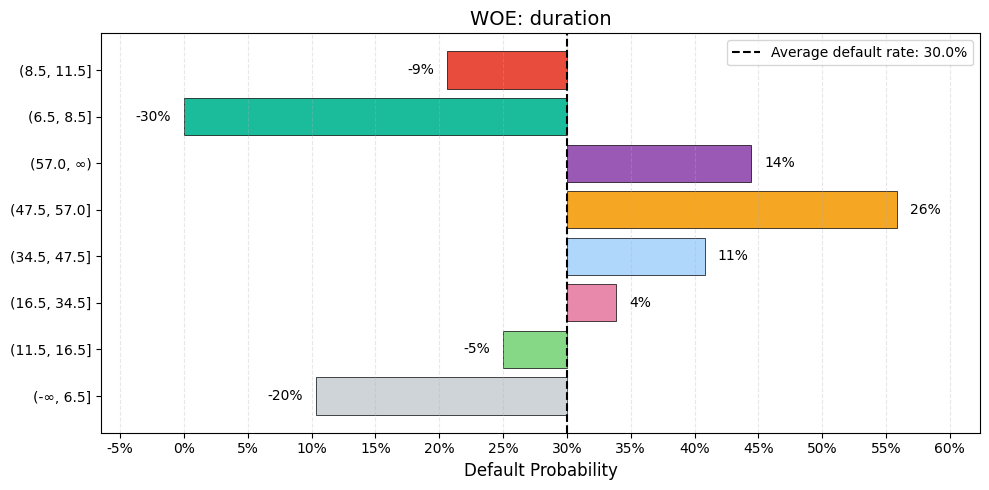

,category,woe,proba,proba_delta
0,"(-∞, 6.5]",-1.3122,0.1034,-0.1966
1,"(11.5, 16.5]",-0.2513,0.2500,-0.0500
2,"(16.5, 34.5]",0.1761,0.3382,0.0382
3,"(34.5, 47.5]",0.4746,0.4079,0.1079
4,"(47.5, 57.0]",1.0837,0.5588,0.2588
5,"(57.0, ∞)",0.6242,0.4444,0.1444
6,"(6.5, 8.5]",-13.9490,0.0000,-0.3000
7,"(8.5, 11.5]",-0.4998,0.2063,-0.0937


In [46]:
import matplotlib.pyplot as plt
from fastwoe import visualize_woe

# Curva de WOE por bin. mode="proba" muestra tasas; mode="logit" muestra WOE en escala log-odds.
# Devuelve ademas el DataFrame con los datos que grafico.
datos_plot = visualize_woe(woe, feature_name="duration", mode="proba", figsize=(10, 5))
plt.show()
datos_plot

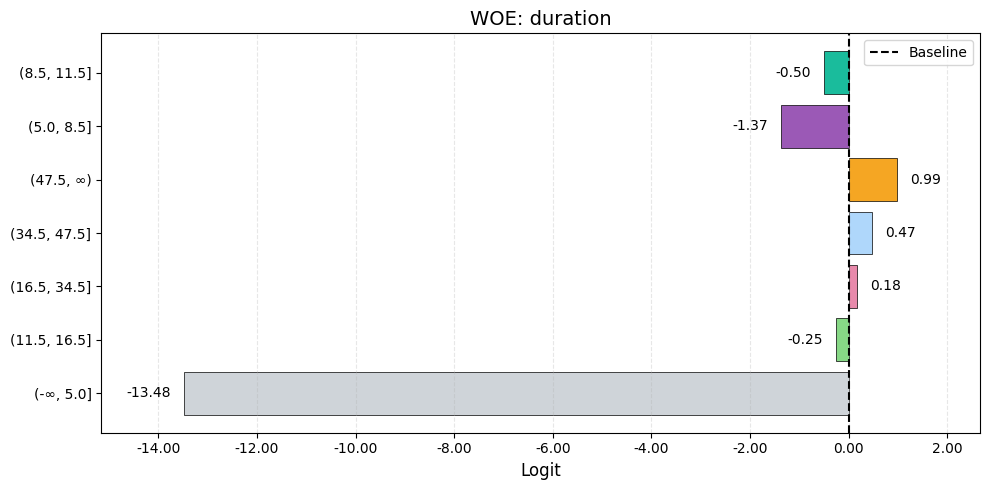

In [47]:
# Escala logit: acá se ve directamente la monotonicidad del WOE.
visualize_woe(woe_mono, feature_name="duration", mode="logit", figsize=(10, 5))
plt.show()

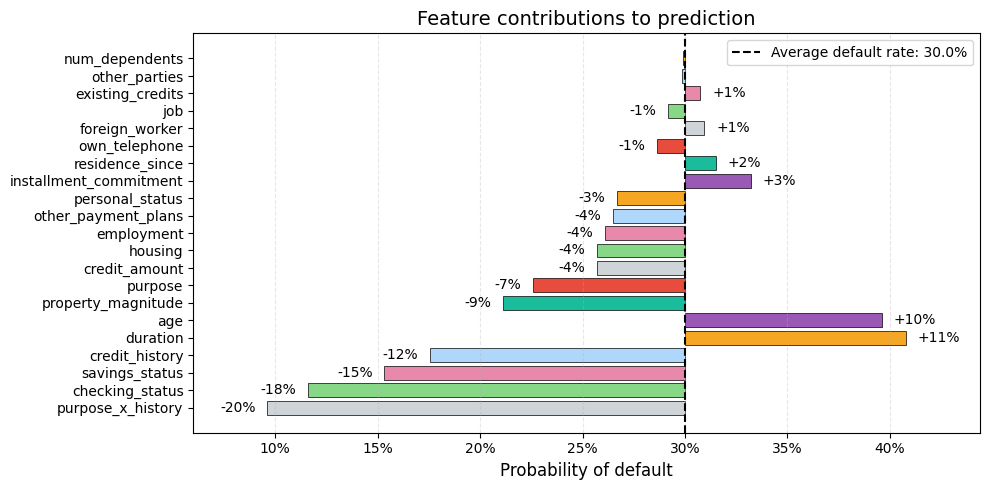

In [48]:
# Waterfall: cómo se arma la decisión de UN caso, variable por variable.
visualize_woe(woe, explanation=expl, figsize=(10, 5))
plt.show()

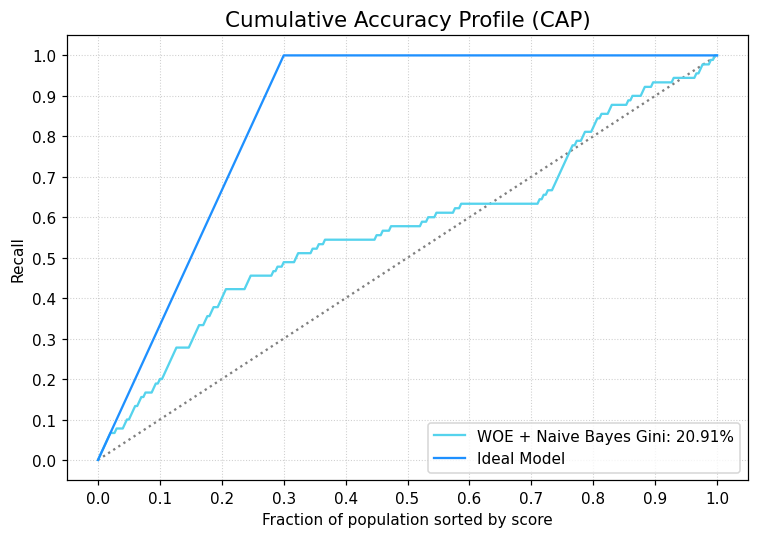

Gini = 0.2091005291005291


In [49]:
from fastwoe import plot_performance

# Curva CAP. Devuelve (figura, ejes, gini).
fig, ax, gini_cap = plot_performance(
    y_te.values, proba[:, 1],
    labels=["WOE + Naive Bayes"], figsize=(7, 5),
)
plt.show()
print(f"Gini = {gini_cap}")

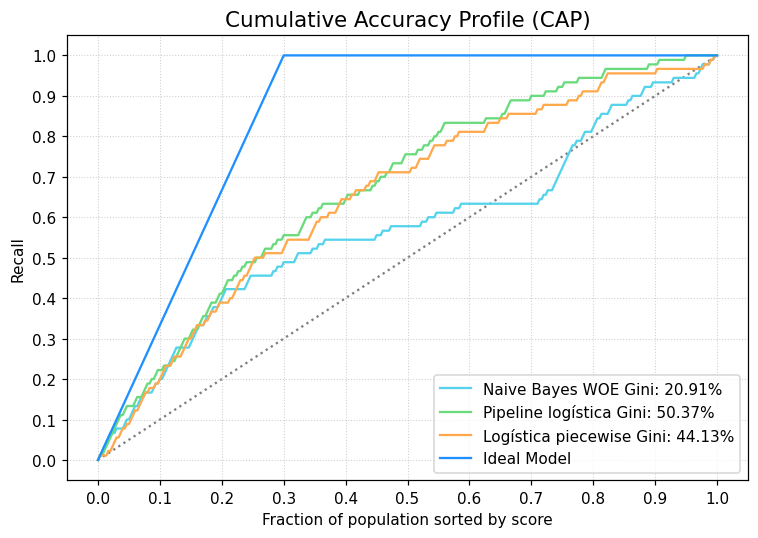

Ginis: [0.2091005291005291, 0.5037037037037037, 0.44126984126984126]


In [50]:
# Comparar varios modelos en la misma curva: se pasa una lista de scores.
fig, ax, ginis = plot_performance(
    y_te.values,
    [proba[:, 1], pipe.predict_proba(X_te)[:, 1], lr_pw.predict_proba(X_te_pw)[:, 1]],
    labels=["Naive Bayes WOE", "Pipeline logística", "Logística piecewise"],
    figsize=(7, 5),
)
plt.show()
print("Ginis:", ginis)

---
## **13. DISPLAY ENRIQUECIDO**

El módulo `display` formatea las tablas de WOE e IV directamente en el notebook, con escala de
color incluida. Es el reemplazo natural de tu `exportar_multiples_bivariados_excel`: mismo objetivo
—leer monotonicidad de un vistazo— sin salir de Python ni depender de `xlsxwriter`.

In [51]:
from fastwoe import style_woe_mapping, style_iv_analysis, StyledDataFrame

# Mapeo de una variable, con formato.
style_woe_mapping(woe.get_mapping("duration"), feature_name="duration", theme="light")

category,count,count_pct,good_count,bad_count,event_rate,woe,woe_se,woe_ci_lower,woe_ci_upper
"(-∞, 6.5]",58,8.2857,52,6,0.1034,-1.3122,0.4312,-2.1572,-0.4671
"(6.5, 8.5]",8,1.1429,8,0,0.0000,-13.9490,0.7303,-15.3804,-12.5177
"(8.5, 11.5]",63,9.0000,50,13,0.2063,-0.4998,0.3113,-1.1100,0.1104
"(11.5, 16.5]",180,25.7143,135,45,0.2500,-0.2513,0.1721,-0.5887,0.0861
"(16.5, 34.5]",272,38.8571,180,92,0.3382,0.1761,0.1282,-0.0751,0.4273
"(34.5, 47.5]",76,10.8571,45,31,0.4079,0.4746,0.2334,0.0171,0.9321
"(47.5, 57.0]",34,4.8571,15,19,0.5588,1.0837,0.3454,0.4067,1.7606
"(57.0, ∞)",9,1.2857,5,4,0.4444,0.6242,0.6708,-0.6906,1.9389


In [52]:
# Análisis de IV de todas las variables, con formato y semáforo de significancia.
style_iv_analysis(woe.get_iv_analysis(), theme="light")

feature,iv,iv_se,iv_ci_lower,iv_ci_upper,iv_significance,n_categories,gini
purpose_x_history,0.9713,0.1719,0.6345,1.3082,Significant,44,0.4017
checking_status,0.6388,0.0917,0.4591,0.8184,Significant,4,0.4023
credit_amount,0.4430,0.1463,0.1562,0.7298,Significant,8,0.2387
credit_history,0.2544,0.0594,0.1381,0.3707,Significant,5,0.2426
duration,0.2465,0.0616,0.1258,0.3673,Significant,8,0.2643
savings_status,0.2335,0.0551,0.1255,0.3414,Significant,5,0.2186
age,0.1562,0.0478,0.0625,0.2499,Significant,7,0.1987
employment,0.1403,0.0425,0.0571,0.2235,Significant,5,0.1940
property_magnitude,0.1402,0.0419,0.0581,0.2223,Significant,4,0.1939
purpose,0.1322,0.0420,0.0499,0.2146,Significant,10,0.1882


In [53]:
# Los decoradores styled / iv_styled permiten formatear la salida de funciones propias.
from fastwoe import styled

@styled(title="Bivariado propio", subtitle="Formateado con el decorador de FastWoe", precision=4)
def mi_bivariado(encoder, variable):
    return encoder.get_mapping(variable)[["category", "count", "event_rate", "woe", "woe_se"]]

mi_bivariado(woe, "checking_status")

category,count,event_rate,woe,woe_se
0<=X<200,188,0.3936,0.4152,0.1493
<0,192,0.4792,0.7639,0.1445
>=200,44,0.2727,-0.1335,0.3385
no checking,276,0.1159,-1.1841,0.1880


---
## **14. MÉTRICAS Y SELECCIÓN DE VARIABLES**

FastWoe trae un módulo de métricas basado en **Somers' D** calculado con Numba, y un algoritmo
de selección *stepwise* que es una alternativa seria al ranking por IV.

In [54]:
from fastwoe import gini_contributions

contribs, gini_total = gini_contributions(proba[:, 1], y_te.values)

print(f"Gini total                    : {gini_total:.6f}")
print(f"Suma de las contribuciones    : {contribs.sum():.6f}   <- coinciden por construcción")

# Qué casos individuales están destruyendo el poder discriminante del score.
peores = pd.DataFrame({
    "contribucion": contribs,
    "p_malo": proba[:, 1],
    "real": y_te.values,
}, index=X_te.index).sort_values("contribucion")

print("\nLos 8 casos que más restan al Gini:")
peores.head(8)

Gini total                    : 0.209101
Suma de las contribuciones    : 0.209101   <- coinciden por construcción

Los 8 casos que más restan al Gini:


,contribucion,p_malo,real
118,-0.0055,0.0000,1
228,-0.0054,0.0000,1
633,-0.0053,0.0000,1
931,-0.0053,0.0000,1
11,-0.0052,0.0000,1
966,-0.0047,0.0000,1
192,-0.0042,0.0000,1
614,-0.0041,0.0000,1


### Selección *stepwise* por Somers' D marginal

`marginal_somersd_selection` es conceptualmente distinto de ordenar por IV: en cada paso ajusta un
modelo con lo ya seleccionado, calcula los **residuos**, y elige la variable que mejor correlaciona
con lo que **todavía no está explicado**. Penaliza la redundancia de forma natural — algo que el
ranking por IV, que es puramente univariado, no hace.

In [55]:
from fastwoe import screening

seleccion = screening.marginal_somersd_selection(
    X_tr, y_tr,
    X_test=X_te, y_test=y_te,
    min_msd=0.01,
    correlation_threshold=0.5,
    random_state=RANDOM_STATE,
    verbose=False,
)

print("Claves:", list(seleccion.keys()))
print("\nVariables seleccionadas, en orden de entrada:")
for i, f in enumerate(seleccion["selected_features"], 1):
    print(f"  {i}. {f}")

Claves: ['selected_features', 'msd_history', 'univariate_somersd', 'model', 'test_performance', 'correlation_matrix']

Variables seleccionadas, en orden de entrada:
  1. checking_status
  2. purpose_x_history
  3. duration
  4. savings_status
  5. property_magnitude
  6. employment
  7. installment_commitment
  8. other_payment_plans
  9. existing_credits
  10. personal_status
  11. other_parties
  12. own_telephone
  13. housing
  14. job
  15. purpose


In [56]:
# Somers' D univariado vs. el aporte marginal en cada paso.
print("--- Somers' D univariado ---")
display(pd.Series(seleccion["univariate_somersd"], name="somersd").sort_values(ascending=False))

print("--- Aporte marginal por paso (msd_history) ---")
display(pd.DataFrame(seleccion["msd_history"]))

--- Somers' D univariado ---


checking_status          0.4023
purpose_x_history        0.4017
duration                 0.2538
credit_history           0.2426
savings_status           0.2186
employment               0.1940
property_magnitude       0.1939
purpose                  0.1882
housing                  0.1476
other_payment_plans      0.1393
personal_status          0.0999
age                      0.0988
installment_commitment   0.0933
credit_amount            0.0658
job                      0.0554
other_parties            0.0467
foreign_worker           0.0435
existing_credits         0.0285
own_telephone            0.0265
residence_since          0.0219
num_dependents           0.0048
Name: somersd, dtype: float64

--- Aporte marginal por paso (msd_history) ---


,0
0,0.4023
1,0.1660
2,0.1267
3,0.0738
4,0.0424
5,0.0479
6,0.0430
7,0.0389
8,0.0330
9,0.0316


In [57]:
# Contraste: el orden por IV NO es el mismo que el orden por aporte marginal.
orden_iv  = woe.get_feature_summary()["feature"].tolist()
orden_msd = seleccion["selected_features"]

pd.DataFrame({
    "ranking": range(1, min(len(orden_iv), len(orden_msd)) + 1),
    "por IV (univariado)": orden_iv[:len(orden_msd)],
    "por Somers' D marginal": orden_msd[:len(orden_iv)],
})

,ranking,por IV (univariado),por Somers' D marginal
0,1,checking_status,checking_status
1,2,purpose_x_history,purpose_x_history
2,3,duration,duration
3,4,credit_history,savings_status
4,5,credit_amount,property_magnitude
5,6,savings_status,employment
6,7,age,installment_commitment
7,8,employment,other_payment_plans
8,9,property_magnitude,existing_credits
9,10,purpose,personal_status


In [58]:
# somersd_shapley: atribución justa de performance entre varios scores, vía valores de Shapley.
scores_dict = {
    "naive_bayes_woe": proba[:, 1],
    "pipeline_log":    pipe.predict_proba(X_te)[:, 1],
    "piecewise_log":   lr_pw.predict_proba(X_te_pw)[:, 1],
}
screening.somersd_shapley(scores_dict, y_te.values)

,score_name,shapley_value,total_somersd,n_scores,n_subsets
0,pipeline_log,0.2351,0.5003,3,8
1,piecewise_log,0.1962,0.5003,3,8
2,naive_bayes_woe,0.0690,0.5003,3,8


---
## **15. ACTUALIZACIÓN INCREMENTAL: `finetune`**

Llega la cosecha del mes siguiente y no querés re-fitear todo desde cero. `finetune` actualiza los
conteos del encoder con los datos nuevos.

`update_prior=False` conserva la tasa base original; `update_prior=True` la recalcula.
En monitoreo de *drift* conviene `False`, para que los WOE sigan siendo comparables contra
la referencia de desarrollo.

In [59]:
woe_ft = FastWoe(random_state=RANDOM_STATE).fit(X_tr, y_tr)

antes = woe_ft.get_mapping("checking_status")[["category", "count", "event_rate", "woe"]]
woe_ft.finetune(X_te, y_te, update_prior=False)
despues = woe_ft.get_mapping("checking_status")[["category", "count", "event_rate", "woe"]]

comparacion = antes.merge(despues, on="category", suffixes=("_antes", "_despues"))
comparacion["delta_woe"] = comparacion["woe_despues"] - comparacion["woe_antes"]
comparacion

,category,count_antes,event_rate_antes,woe_antes,count_despues,event_rate_despues,woe_despues,delta_woe
0,0<=X<200,188,0.3936,0.4152,81,0.3827,0.3693,-0.0459
1,<0,192,0.4792,0.7639,82,0.5244,0.9449,0.1810
2,>=200,44,0.2727,-0.1335,19,0.1053,-1.2928,-1.1592
3,no checking,276,0.1159,-1.1841,118,0.1186,-1.1580,0.0261


> **Uso práctico: monitoreo de estabilidad.** Fiteás en la ventana de desarrollo, hacés `finetune`
> con la cosecha nueva y mirás `delta_woe`. Un salto grande en un bin es una señal de *drift*
> en esa variable, detectada sin construir un PSI aparte.

---
## **16. MULTICLASS (BREVE)**

Con un target de 3+ clases, FastWoe hace **one-vs-rest**: genera un WOE por clase y por variable.
En scoring crediticio lo habitual es binario, pero sirve para segmentaciones tipo
*al día / mora temprana / mora dura*.

In [60]:
# Target de 3 clases construido a partir del riesgo estimado, solo para la demo.
p_riesgo = woe.predict_proba(X_tr)[:, 1]
y_multi = pd.Series(
    pd.qcut(p_riesgo, q=3, labels=[0, 1, 2]).astype(int),
    index=X_tr.index, name="riesgo_3c",
)
print(y_multi.value_counts().sort_index().to_dict())

woe_mc = FastWoe(random_state=RANDOM_STATE).fit(X_tr, y_multi)
X_mc = woe_mc.transform(X_tr)

print(f"\n{X_tr.shape[1]} variables  ->  {X_mc.shape[1]} columnas (una por variable y clase)")
print("Nomenclatura:", list(X_mc.columns)[:6])
X_mc.head()

{0: 233, 1: 233, 2: 234}

21 variables  ->  63 columnas (una por variable y clase)
Nomenclatura: ['checking_status_class_0', 'checking_status_class_1', 'checking_status_class_2', 'duration_class_0', 'duration_class_1', 'duration_class_2']


,checking_status_class_0,checking_status_class_1,checking_status_class_2,duration_class_0,duration_class_1,duration_class_2,credit_history_class_0,credit_history_class_1,credit_history_class_2,purpose_class_0,purpose_class_1,purpose_class_2,credit_amount_class_0,credit_amount_class_1,credit_amount_class_2,savings_status_class_0,savings_status_class_1,savings_status_class_2,employment_class_0,employment_class_1,employment_class_2,installment_commitment_class_0,installment_commitment_class_1,installment_commitment_class_2,personal_status_class_0,...,age_class_2,other_payment_plans_class_0,other_payment_plans_class_1,other_payment_plans_class_2,housing_class_0,housing_class_1,housing_class_2,existing_credits_class_0,existing_credits_class_1,existing_credits_class_2,job_class_0,job_class_1,job_class_2,num_dependents_class_0,num_dependents_class_1,num_dependents_class_2,own_telephone_class_0,own_telephone_class_1,own_telephone_class_2,foreign_worker_class_0,foreign_worker_class_1,foreign_worker_class_2,purpose_x_history_class_0,purpose_x_history_class_1,purpose_x_history_class_2
10,-0.1369,-0.4903,0.5397,16.7561,-16.0608,-16.0630,-0.0565,-0.0062,0.0613,-0.2748,0.1057,0.1499,0.2594,0.1737,-0.4924,-0.0967,-0.1646,0.2453,-0.1520,-0.7986,0.7556,0.1075,0.0288,-0.1415,0.1563,...,-2.5300,0.1070,0.1070,-0.2262,0.6465,-0.6708,-0.1162,-0.0426,-0.1058,0.1426,-0.0045,0.0650,-0.0616,0.0224,0.0224,-0.0453,0.1704,-0.0087,-0.1710,-0.0588,0.0088,0.0488,-0.1967,-0.1410,0.3124
82,0.1767,0.7098,-1.2737,-0.3449,0.5170,-0.2391,-0.0565,-0.0062,0.0613,-0.6730,0.0667,0.4853,0.2594,0.1737,-0.4924,-0.2297,-0.3545,0.5156,0.1975,-0.1289,-0.0784,0.1075,0.0288,-0.1415,0.1563,...,-15.7485,0.1070,0.1070,-0.2262,0.6465,-0.6708,-0.1162,-0.0426,-0.1058,0.1426,0.4946,-0.0849,-0.4875,0.0224,0.0224,-0.0453,0.1704,-0.0087,-0.1710,-0.0588,0.0088,0.0488,0.1357,0.3276,-0.5349
827,0.1767,0.7098,-1.2737,-0.3449,0.5170,-0.2391,-0.4033,-1.8697,1.4361,-0.6730,0.0667,0.4853,1.5426,-0.1520,-14.2224,-0.0967,-0.1646,0.2453,0.1975,-0.1289,-0.0784,0.0907,-0.1549,0.0580,-0.0409,...,0.4988,-0.2027,-0.4748,0.5835,-0.0735,0.2330,-0.1737,0.0572,0.2173,-0.2976,-0.0045,0.0650,-0.0616,-0.1222,-0.1222,0.2306,0.1704,-0.0087,-0.1710,-0.0588,0.0088,0.0488,-0.6910,-14.2203,2.0752
410,-0.1369,-0.4903,0.5397,-0.3449,0.5170,-0.2391,-0.0565,-0.0062,0.0613,0.2358,0.5011,-0.9598,0.2594,0.1737,-0.4924,-0.0967,-0.1646,0.2453,-0.1572,0.4550,-0.3526,-0.2210,0.1612,0.0465,0.1563,...,-14.2224,0.1070,0.1070,-0.2262,-0.0735,0.2330,-0.1737,-0.0426,-0.1058,0.1426,-0.0045,0.0650,-0.0616,0.0224,0.0224,-0.0453,-0.2710,0.0127,0.2361,-0.0588,0.0088,0.0488,-0.0932,0.6953,-0.7775
48,0.1767,0.7098,-1.2737,-0.1755,0.5969,-0.5222,0.3101,0.5291,-1.1551,-0.2748,0.1057,0.1499,15.8318,-15.1366,-15.1387,-0.0967,-0.1646,0.2453,0.1975,-0.1289,-0.0784,0.3899,-0.3371,-0.0967,-0.0409,...,0.4988,0.1070,0.1070,-0.2262,-0.0735,0.2330,-0.1737,0.0572,0.2173,-0.2976,0.4946,-0.0849,-0.4875,0.0224,0.0224,-0.0453,0.1704,-0.0087,-0.1710,-0.0588,0.0088,0.0488,0.1845,0.9104,-1.8761


In [61]:
# Mapeo y predicciones para una clase puntual.
display(woe_mc.get_mapping("duration", class_label=2))

proba_c2 = woe_mc.predict_proba_class(X_tr, class_label=2)
ci_c2    = woe_mc.predict_ci_class(X_tr, class_label=2, alpha=0.05)

print(f"P(clase 2) shape: {proba_c2.shape} | IC shape: {ci_c2.shape}")
print(f"predict_proba (todas las clases): {woe_mc.predict_proba(X_tr).shape}")

,category,count,count_pct,good_count,bad_count,event_rate,woe,woe_se,woe_ci_lower,woe_ci_upper
0,"(-∞, 5.0]",5,0.7143,5,0,0.0000,-13.5293,0.9129,-15.3185,-11.7401
1,"(5.0, 8.5]",61,8.7143,47,14,0.2295,-0.5222,0.3045,-1.1190,0.0745
2,"(8.5, 11.5]",63,9.0000,63,0,0.0000,-16.0630,0.5916,-17.2225,-14.9034
3,"(11.5, 16.5]",180,25.7143,129,51,0.2833,-0.2391,0.1654,-0.5633,0.0851
4,"(16.5, 34.5]",272,38.8571,173,99,0.3640,0.1307,0.1260,-0.1163,0.3777
5,"(34.5, 51.0]",109,15.5714,49,60,0.5505,0.8914,0.1925,0.5140,1.2688
6,"(51.0, ∞)",10,1.4286,0,10,1.0000,14.9113,0.6901,13.5588,16.2638


P(clase 2) shape: (700,) | IC shape: (700, 2)
predict_proba (todas las clases): (700, 3)


---
## **17. CIERRE: EQUIVALENCIAS CON `woe_example/utils.py`**

Traducción directa función por función. El análisis completo —incluidas las diferencias de
convención y las rutas de adopción— está en [`README.md`](README.md).

| Tu `utils.py` | Equivalente en FastWoe |
|---|---|
| `clasificar_variables()` | automático, vía `numerical_threshold` |
| `calcular_metricas_bin()` | interno; se ve en `get_mapping()` |
| `calcular_bivariados()` | `fit()` + `get_mapping()` / `get_feature_stats()` / `get_iv_analysis()` |
| `discretizar_variables()` | `binning_method` + `tree_kwargs` / `binner_kwargs` |
| `percentiles_precalculados` | `fit(train)` → `transform(test)` |
| `calcular_woe_mapping()` | `get_all_mappings()` |
| `aplicar_woe()` | `transform()` |
| `exportar_multiples_bivariados_excel()` | `style_woe_mapping()` / `style_iv_analysis()` |
| *(no existe)* | `woe_se`, IC por bin, `get_iv_analysis()` con significancia |
| *(no existe)* | `monotonic_cst` — monotonicidad forzada |
| *(no existe)* | `assign_pieces()` + logística → el paso a *scorecard* |

**Las dos diferencias de convención**, en una línea cada una:

1. **Signo** — `WOE_utils = −WOE_fastwoe`. Vos usás `ln(%buenos/%malos)`, FastWoe usa `ln(P(malo)/P(bueno))`.
2. **Escala del IV** — `IV_utils ≈ 100 × IV_fastwoe`, porque guardás los porcentajes en puntos porcentuales.

**Lo que NO es una diferencia:** el centrado. Al calcular el WOE sobre `%buenos_total` y `%malos_total`,
tu fórmula **ya está centrada en la tasa poblacional**, igual que la resta explícita del *prior* que hace
FastWoe. Las dos son la misma cosa cambiada de signo:

```
ln( (bᵢ/B) / (mᵢ/M) )  =  −[ ln(mᵢ/bᵢ) − ln(M/B) ]
                            └ log-odds bin ┘ └ prior ┘
```

La verificación numérica de las dos —sobre `checking_status` de este mismo dataset— está en
el [`README.md`](README.md), §4.

In [62]:
# Cierre: el bin más riesgoso tiene WOE POSITIVO en FastWoe, negativo en tu convención.
m = woe.get_mapping("duration")[["category", "count", "event_rate", "woe"]]
peor = m.loc[m["event_rate"].idxmax()]

print(f"Bin más riesgoso : {peor['category']}")
print(f"  tasa de malos  : {peor['event_rate']:.2%}")
print(f"  WOE (FastWoe)  : {peor['woe']:+.4f}")
print(f"  WOE (tu utils) : {-peor['woe']:+.4f}   <- signo invertido")

Bin más riesgoso : (47.5, 57.0]
  tasa de malos  : 55.88%
  WOE (FastWoe)  : +1.0837
  WOE (tu utils) : -1.0837   <- signo invertido
